# Get Data

### Connection

postgres connection

In [1]:
import os

from config import Base
from dotenv import load_dotenv
from sqlalchemy import Engine, create_engine
from sqlalchemy.orm import Session

try:
    load_dotenv()

    db_url = os.getenv("DATABASE_URL")

    if not db_url:
        print("Erreur : DATABASE_URL est vide ou non définie.")


    if db_url.startswith("postgres://"):
        db_url = db_url.replace("postgres://", "postgresql://", 1)

    engine: Engine = create_engine(db_url)
    Base.metadata.create_all(engine)
    session: Session = Session(engine)

except Exception as e:
    print("DB error:", e)
    raise Exception(e)

if session:
    print("connection succeded")
else :
    print("connection failed")


connection succeded


### Request

SQL get user and practice 

In [2]:
from config import Practice, User
from sqlalchemy import func, select, text
from sqlalchemy.orm import aliased

query = (
    session.query(
        Practice,
    )
)

practices = query.all()

### Format data

list data

In [3]:
from datetime import date


def calculate_age(birth_date: date) -> int:
    today = date.today()

    return (
        today.year
        - birth_date.year
        - ((today.month, today.day) < (birth_date.month, birth_date.day))
    )

header = ["user_id", "user_physical_activity_level", "user_bmi", "user_age", "favorite_exercice_categorie", "exercice name"]

datas = []

for practice in practices:
    exercice = practice.exercise
    user : User = practice.user

    data = [
        user.physical_activity_level.lower(), float(user.bmi), calculate_age(user.birthdate), user.favorite_exercise_category, exercice.name
    ]
    datas.append(data)

print(datas[0])
print(len(datas))

['moderate', 17.89, 63, 'Musculation', 'Développé Unilatéral au Kettlebell']
587536


Close db connection

In [4]:
session.close()

convert data to pandas dataframe

In [5]:
import pandas as pd

df = pd.DataFrame(datas, columns=header)

ValueError: 6 columns passed, passed data had 5 columns

### Check data

df

In [ ]:
df.shape


(587536, 5)

In [ ]:
df.columns


Index(['user_physical_activity_level', 'user_bmi', 'user_age',
       'favorite_exercice_categorie', 'exercice name'],
      dtype='str')

In [ ]:
df.info()        # data type + missing value

<class 'pandas.DataFrame'>
RangeIndex: 587536 entries, 0 to 587535
Data columns (total 5 columns):
 #   Column                        Non-Null Count   Dtype  
---  ------                        --------------   -----  
 0   user_physical_activity_level  587536 non-null  str    
 1   user_bmi                      587536 non-null  float64
 2   user_age                      587536 non-null  int64  
 3   favorite_exercice_categorie   587536 non-null  str    
 4   exercice name                 587536 non-null  str    
dtypes: float64(1), int64(1), str(3)
memory usage: 22.4 MB


In [ ]:
df.head()


,user_physical_activity_level,user_bmi,user_age,favorite_exercice_categorie,exercice name
0,moderate,17.89,63,Musculation,Développé Unilatéral au Kettlebell
1,moderate,17.89,63,Musculation,Curl Concentration à la Poulie
2,moderate,17.89,63,Musculation,Extension Hip Thrust à la Machine
3,moderate,17.89,63,Musculation,Fentes Arrière aux Haltères
4,moderate,17.89,63,Musculation,Développé Unilatéral aux Haltères


In [ ]:
df.tail()

,user_physical_activity_level,user_bmi,user_age,favorite_exercice_categorie,exercice name
587531,moderate,18.8,18,Musculation,Rowing Yates à la Barre
587532,moderate,18.8,18,Musculation,Rowing Unilatéral à la Poulie
587533,moderate,18.8,18,Musculation,Curl Biceps à la Barre
587534,moderate,18.8,18,Musculation,Soulevé de terre Unilatéral à la Barre
587535,moderate,18.8,18,Musculation,Curl Zottman à la Barre


data repartition

In [ ]:
df.describe(include='all')

,user_physical_activity_level,user_bmi,user_age,favorite_exercice_categorie,exercice name
count,587536,587536.000000,587536.000000,587536,587536
unique,3,NaN,NaN,3,231
top,moderate,NaN,NaN,Musculation,Développé Assis aux Haltères
freq,395615,NaN,NaN,585827,7743
mean,NaN,23.729496,38.960600,NaN,NaN
std,NaN,3.750207,12.818687,NaN,NaN
min,NaN,8.700000,18.000000,NaN,NaN
25%,NaN,21.190000,28.000000,NaN,NaN
50%,NaN,23.900000,38.000000,NaN,NaN
75%,NaN,26.400000,49.000000,NaN,NaN


In [ ]:
df.isnull().sum()

user_physical_activity_level    0
user_bmi                        0
user_age                        0
favorite_exercice_categorie     0
exercice name                   0
dtype: int64

cut it too avoid bad readability of diagram

In [ ]:
sample_df = df.sample(n=2000, random_state=42)

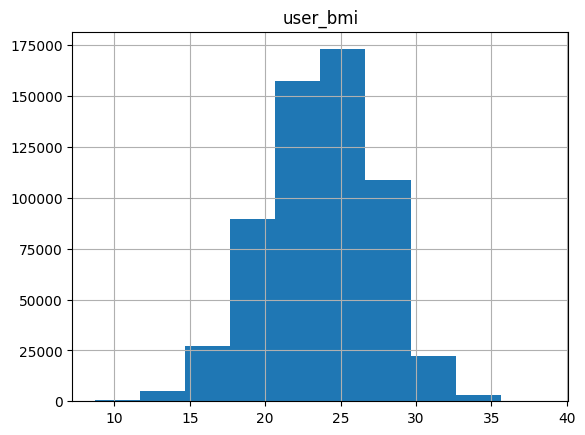

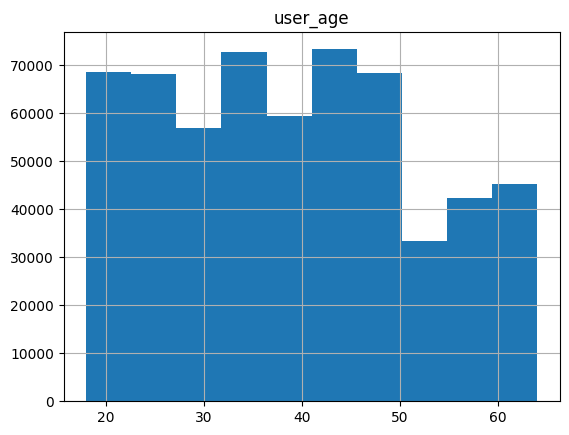

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

columns = ["user_bmi", "user_age"]

for column in columns:
    df[column].hist()
    plt.title(column)
    plt.show()

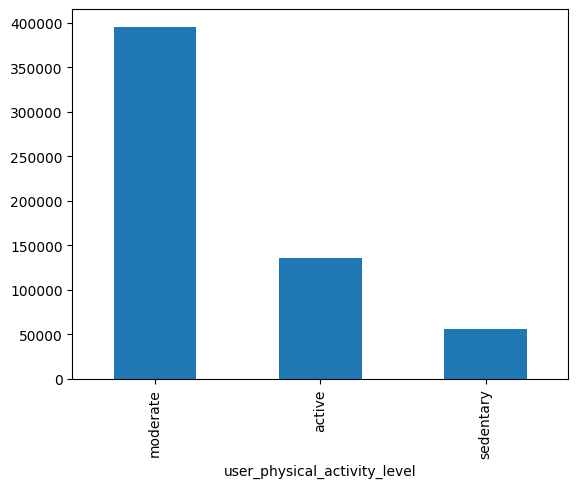

In [ ]:
df["user_physical_activity_level"].value_counts().plot(kind="bar")
plt.show()

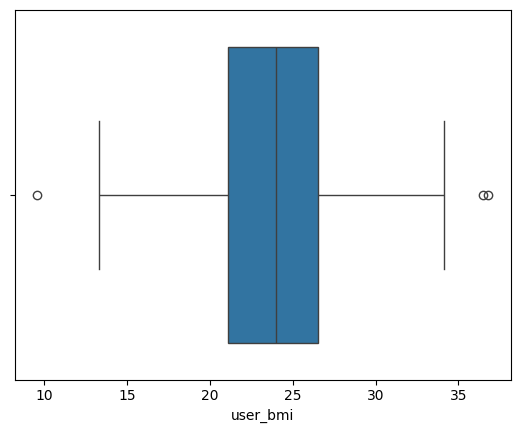

In [ ]:
sns.boxplot(x=sample_df["user_bmi"])
plt.show()

In [ ]:
print("Age range:", df["user_age"].min(), "to", df["user_age"].max())
print("BMI range:", df["user_bmi"].min(), "to", df["user_bmi"].max())

Age range: 18 to 64
BMI range: 8.7 to 38.61


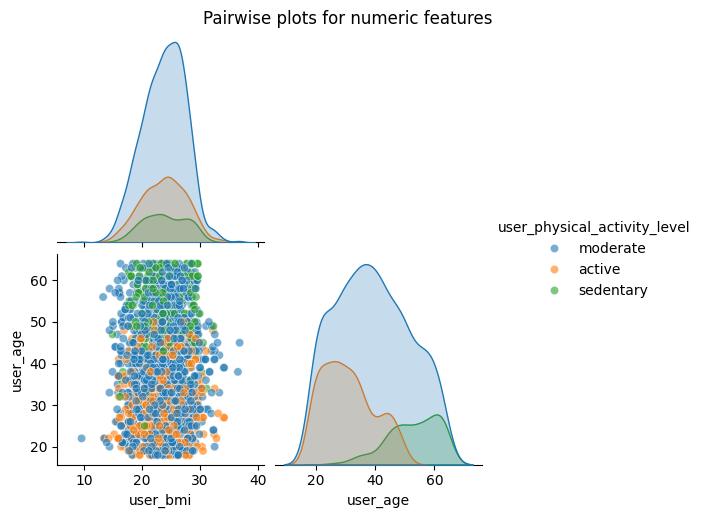

In [ ]:
sns.pairplot(
    sample_df,
    vars=["user_bmi", "user_age"],
    hue="user_physical_activity_level",
    palette="tab10",
    corner=True,
    plot_kws={"alpha": 0.6},
)
plt.suptitle("Pairwise plots for numeric features", y=1.02)
plt.show()

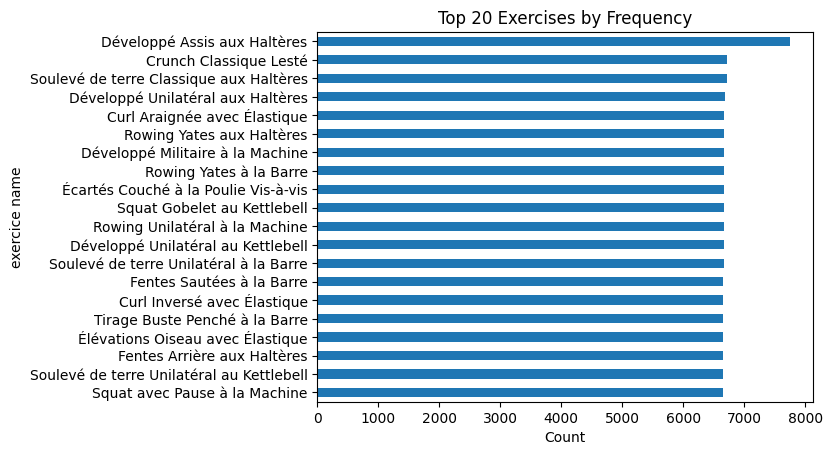

In [ ]:
# Exercise frequency and top exercises
exercise_counts = df["exercice name"].value_counts().head(20)
exercise_counts.plot(kind="barh")
plt.title("Top 20 Exercises by Frequency")
plt.xlabel("Count")
plt.gca().invert_yaxis()
plt.show()

### Nettoyage

remove bad data

convert enum to numerical

In [ ]:
mapping = {
    "sedentary": 0,
    "moderate": 1,
    "active": 2
}

df["user_physical_activity_level"] = df["user_physical_activity_level"].map(mapping)

print(df["user_physical_activity_level"][0])


1


In [ ]:
mapping = {
    "poids du corps": 0,
    "musculation": 1,
    "cardio": 2
}

df["favorite_exercice_categorie"] = df["favorite_exercice_categorie"].map(lambda x: x.lower() if isinstance(x, str) else x).map(mapping)

print(df["favorite_exercice_categorie"][0])


1


quick data paranthesis after converting str to int

In [ ]:
df = df.dropna(subset=['user_bmi', 'user_age', 'exercice name', 'favorite_exercice_categorie', 'user_physical_activity_level'])

print(len(df))

587536


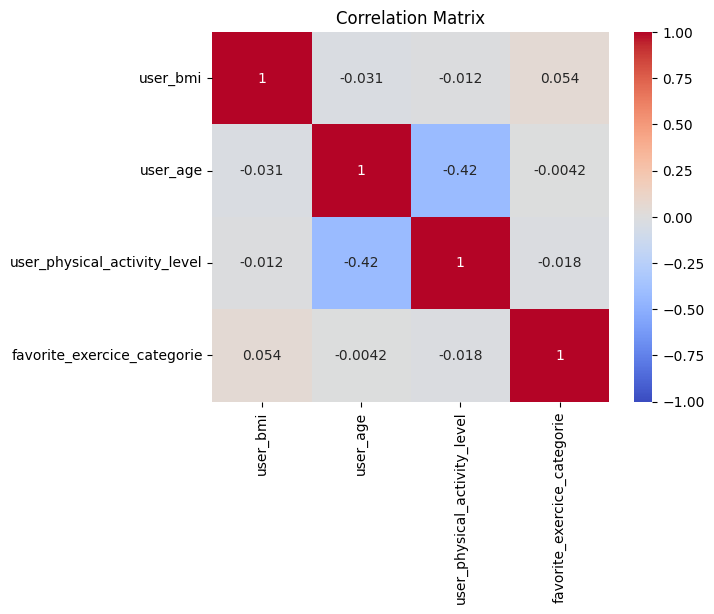

In [ ]:
numeric_cols = ["user_bmi", "user_age", "user_physical_activity_level", "favorite_exercice_categorie"]
corr = df[numeric_cols].corr()
sns.heatmap(corr, annot=True, cmap="coolwarm", vmin=-1, vmax=1)
plt.title("Correlation Matrix")
plt.show()

In [ ]:
rare_classes = df["exercice name"].value_counts()
rare_classes = rare_classes[rare_classes < 10]

print(rare_classes)

counts = df["exercice name"].value_counts()

df_filtered = df[
    df["exercice name"].isin(counts[counts >= 20].index)
]
print(len(df_filtered["exercice name"].unique()))

exercice name
Tractions Lestées                           9
Relevé de jambes Suspendu Poids du corps    9
Crunch à la Poulie Poids du corps           9
Relevé de jambes au Sol Poids du corps      5
Squat avec Pause Poids du corps             5
Pompes Larges                               5
Crunch Russian Twist Poids du corps         5
Pompes Claquées                             5
Pompes Sur les genoux                       5
Squat Classique Poids du corps              4
Crunch Classique Poids du corps             4
Squat Sumo Poids du corps                   4
Squat Pistolet Poids du corps               4
Extension Glute Bridge Poids du corps       4
Tractions Supination                        4
Crunch Bicyclette Poids du corps            4
Name: count, dtype: int64
205


### Prepare Data

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

FEATURES = ['user_physical_activity_level', 'user_bmi', 'user_age', 'favorite_exercice_categorie']
X = df_filtered[FEATURES]

le = LabelEncoder()
y  = le.fit_transform(df_filtered['exercice name'])
user_ids = df_filtered['user_id']
print('Classes :', le.classes_)

X_train, X_test, y_train, y_test, user_ids_train, user_ids_test = train_test_split(
    X, y, user_ids, test_size=0.5, random_state=42, stratify=y)
print(f'Train: {len(X_train)} | Test: {len(X_test)}')

Classes : ['Course Fractionné' 'Course Sprint' 'Course en Côte' 'Course sur Tapis'
 'Crunch Bicyclette à la Poulie' 'Crunch Classique Lesté'
 'Crunch Classique à la Poulie' 'Crunch Inversé Lesté'
 'Crunch Inversé à la Poulie' 'Crunch Russian Twist Lesté'
 'Crunch Russian Twist à la Poulie' 'Crunch V-Up Lesté'
 'Crunch V-Up à la Poulie' 'Crunch à la Poulie Lesté'
 'Crunch à la Poulie à la Poulie' 'Curl Araignée aux Haltères'
 'Curl Araignée avec Élastique' 'Curl Araignée à la Barre'
 'Curl Araignée à la Poulie' 'Curl Biceps aux Haltères'
 'Curl Biceps avec Élastique' 'Curl Biceps à la Barre'
 'Curl Concentration aux Haltères' 'Curl Concentration à la Barre'
 'Curl Concentration à la Poulie' 'Curl Inversé avec Élastique'
 'Curl Inversé à la Poulie' 'Curl Marteau aux Haltères'
 'Curl Marteau à la Barre' 'Curl Marteau à la Poulie'
 'Curl Pupitre aux Haltères' 'Curl Pupitre avec Élastique'
 'Curl Pupitre à la Barre' 'Curl Pupitre à la Poulie'
 'Curl Zottman aux Haltères' 'Curl Zottman à la 

## Train Ai

settings

In [ ]:
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import make_scorer, top_k_accuracy_score
from sklearn.model_selection import RandomizedSearchCV
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

model = make_pipeline(
    StandardScaler(),
    LogisticRegression(solver="saga",
                       max_iter=1500)
)

# params = [
#     {
#         "logisticregression__solver": ["lbfgs"],
#         "logisticregression__C": [0.01, 0.1, 1, 10, 100],
#         "logisticregression__max_iter": [1000, 2000, 5000]
#     },
#     {
#         "logisticregression__solver": ["saga"],
#         "logisticregression__l1_ratio": [0.0, 0.5, 1.0],
#         "logisticregression__C": [0.01, 0.1, 1, 10, 100],
#         "logisticregression__max_iter": [1000, 2000, 5000]
#     }
# ]

params = [
    {
        "logisticregression__l1_ratio": [0.0, 0.5, 1.0],
        "logisticregression__C": [0.01, 0.1, 1, 10, 100],
    }
]

all_labels = np.unique(y)

top5 = make_scorer(
    top_k_accuracy_score,
    k=5,
    response_method="predict_proba",
    labels=all_labels
)

random_search_regression = RandomizedSearchCV(
    model,
    param_distributions= params,
    n_iter=5,
    cv=3,
    scoring=top5,
    random_state=42,
    verbose=3
)

In [ ]:
from sklearn.ensemble import RandomForestClassifier

model = make_pipeline(
    StandardScaler(),
    RandomForestClassifier()
)

# params = [
#     {
#         "logisticregression__solver": ["lbfgs"],
#         "logisticregression__C": [0.01, 0.1, 1, 10, 100],
#         "logisticregression__max_iter": [1000, 2000, 5000]
#     },
#     {
#         "logisticregression__solver": ["saga"],
#         "logisticregression__l1_ratio": [0.0, 0.5, 1.0],
#         "logisticregression__C": [0.01, 0.1, 1, 10, 100],
#         "logisticregression__max_iter": [1000, 2000, 5000]
#     }
# ]

params = [
    {
        "logisticregression__solver": ["saga"],
        "logisticregression__C": [0.01, 0.1, 1],
        "logisticregression__max_iter": [1000]
    }
]

all_labels = np.unique(y)

top5 = make_scorer(
    top_k_accuracy_score,
    k=5,
    response_method="predict_proba",
    labels=all_labels
)

random_search_tree = RandomizedSearchCV(
    model,
    param_distributions= params,
    n_iter=10,
    cv=3,
    scoring=top5,
    random_state=42,
    verbose=3
)

train

In [ ]:
random_search_regression.fit(X_train, y_train)

best_model_regression = random_search_regression.best_estimator_

Fitting 3 folds for each of 5 candidates, totalling 15 fits


In [ ]:
random_search_tree.fit(X_train, y_train)

best_model_tree = random_search_tree.best_estimator_

Check performance

In [ ]:
import numpy as np

probs_regression = best_model_regression.predict_proba(X_test)
probs_tree = best_model_tree.predict_proba(X_test)

top_k = 5

top_k_accuracy_regression = top_k_accuracy_score(y_true=y_test, y_score=probs_regression, k=top_k)
top_k_accuracy_tree = top_k_accuracy_score(y_true=y_test, y_score=probs_tree, k=top_k)

print(top_k_accuracy_regression)
print(top_k_accuracy_tree)

best_model = best_model_regression if top_k_accuracy_regression >= top_k_accuracy_tree else best_model_tree

In [ ]:
probs = best_model.predict_proba(X_test)

top_k_accuracy = top_k_accuracy_score(y_true=y_test, y_score=probs_tree, k=top_k)

print(top_k_accuracy)

In [ ]:
from sklearn.metrics import accuracy_score, f1_score, mean_absolute_error, precision_score

user_ids_test = user_ids_test.to_numpy()

y_pred = best_model.predict(X_test)

true_sets = {
    user_id: set(y_test[user_ids_test == user_id])
    for user_id in np.unique(user_ids_test)
}

one_of_correct = [
    pred in true_sets[user_id]
    for pred, user_id in zip(y_pred, user_ids_test)
]

one_of_accuracy = np.mean(one_of_correct)

metrics = {
    "one_of_accuracy": one_of_accuracy,
    "accuracy": accuracy_score(y_test, y_pred),
    "precision": precision_score(y_test, y_pred, average="micro"),
    "f1": f1_score(y_test, y_pred, average="micro"),
    "l1": mean_absolute_error(y_test, y_pred)
}

on average where is the right answer

In [ ]:
place = []

sorted_probs =  np.argsort(probs, axis=1)[:, ::-1]

for sorted_prob in range(len(sorted_probs)):
    i = 1
    while sorted_probs[sorted_prob][i-1] != y_test[sorted_prob]:
        i+=1
    place.append(i)

print(np.average(place))

Learning curve

In [ ]:
from sklearn.model_selection import learning_curve

train_sizes, train_scores, val_scores = learning_curve(
    best_model,
    X,
    y,
    cv=4,
    scoring=top5,
    train_sizes=[0.5, 0.6, 0.8, 0.9]
)

In [ ]:
train_mean = train_scores.mean(axis=1)
val_mean = val_scores.mean(axis=1)

plt.plot(train_sizes, train_mean, label="Training score")
plt.plot(train_sizes, val_mean, label="Validation score")

plt.xlabel("Training set size")
plt.ylabel("Accuracy")
plt.title("Learning Curve (Best RandomizedSearchCV Model)")
plt.legend()
plt.show()

Feature importance

In [ ]:
logreg = best_model.named_steps["logisticregression"]

importance = pd.Series(
    logreg.coef_[0],
    index=X.columns
)

importance = importance.sort_values(key=np.abs, ascending=False)

print(importance)

The data has few extreme BMI below 15 above 30 most sedentary user are 40 up so we should check how it behave with those

the general ai is at around 26% and on average the expected "answer" is in whithin the 17 range but the ai is a recomendation it doesn't give a one true answer but a fitting answer should update to multi label

the learning curve are close so the model seem to be fine with data not in training but the ai accuracy is low but as previously mentioned there isn't realy an answer 

the curve do not get closer

the model could integrade user experiance once we have it

In [ ]:
import os

import joblib

os.makedirs('../models', exist_ok=True)
joblib.dump(best_model, '../models/model.pkl')
joblib.dump(le,  '../models/encoder.pkl')
print('models/model.pkl and models/encoder.pkl created')